# Сборный проект

**Описание проекта**

Вы работаете в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Вам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

Перед вами данные до 2016 года. Представим, что сейчас декабрь 2016 г., и вы планируете кампанию на 2017-й. Нужно отработать принцип работы с данными. Неважно, прогнозируете ли вы продажи на 2017 год по данным 2016-го или же 2027-й — по данным 2026 года.

В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

**Импортируем все необходимые библиотеки для исследования:**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

### Шаг 1. Загрузка данных

#### Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним его в датафрейм.

Путь к файлу: `/datasets/games.csv`

In [2]:
games = pd.read_csv('/datasets/games.csv')

#### Выведем первые строки набора данных. Изучим общую информацию о датафрейме.

Выведем первые 10 строк сохранённого датафрейма:

In [3]:
games.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Из вывода первых строк видно, что данные отобразились "приемлемо", то есть не съехали из одного столбца в другой и не записались в один столбец склеенной строкой.

Теперь для лучшего понимания данных, хранящихся в датафрейме, выведем информацию о нём методом `.info()`:

In [4]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


После вызова метода `.info()` можно говорить о следующем:
- не все строки заполнены - существуют пропуски, которые необходимо будет обработать
- необходимо будет преобразовать типы данных некоторых столбцов: `'Year_of_Release'`, `'Critic_Score'`, `'User_Score'`
- необходимо будет заменить названия столбцов - привести к правильному виду записи (прописные буквы,  латинский алфавит, "змеевидная" запись(через нижнее подчеркивание))

Проделаем вышеописанные шаги в следующем шаге: **Шаг 2**.

### Шаг 2. Предобработка данных

#### Заменим названия столбцов

Как было выяснено в **пункте 1.2**, названия столбцов не соответствуют общепринятым нормам записи, поэтому изменим их на *правильные*.

Создадим два списка: `old_names` - куда запишем текущие названия столбцов датафрейма `games`, `new_names` - новый список, где будут храниться правильные названия столбцов. 

Так как столбцов немного и чтобы оптимизировать процесс переименования - воспользуемся циклом *for*.

Циклом *for* пройдёмся по данным в `old_names` и методом `.lower()` преобразуем их к строчному виду, после добавим результат в `new_names` методом `.append()`.

In [5]:
old_names = games.columns
new_names = []
for i in range (len(old_names)):
    new_names.append(old_names[i].lower())

После этого снова воспользуемся циклом *for* и постепенно будем изменять старые названия на новый:

In [6]:
for i in range(len(new_names)):
    games = games.rename(columns={old_names[i] : new_names[i]})

Выведем первые строки, чтобы убедиться в переименовании столбцов:

In [7]:
games.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Переименование столбцов прошло успешно.

#### Преобразование данных в нужные типы. 

В **пункте 1.2** мы также определили, что некоторые столбцы - теперь уже `'year_of_release'`, `'critic_score'`, `'user_score'` - имеют неправильный тип данных. Рассмотрим эти столбцы и определим к какому типу данных их лучше преобразовать.

Рассмотрим столбец `'critic_score'`. Из первых строк, которые мы выводили ранее, трудно сказать, какие в нём могут быть значения: целые или вещественные. В связи с этим воспользуемся методом `.unique()`, чтобы найти все уникальные значения и понять какой тип они имеют, и `.sort_values()`, чтобы было легче анализировать полученную информацию. После выведем результат на экран: 

In [8]:
games['critic_score'].sort_values().unique()

array([13., 17., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29.,
       30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42.,
       43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55.,
       56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68.,
       69., 70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81.,
       82., 83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93., 94.,
       95., 96., 97., 98., nan])

Из полученных результатов можно говорить о том, что столбец `'critic_score'` датафрейма `games` нужно преобразовать к целочисленному типу данных, так как в нём нет **ни одного** вещественного числа.

Для преобразования к другому типу данных воспользуемся методом `.astype()`:

In [9]:
games['critic_score'] = games['critic_score'].astype('Int64')

Теперь рассмотрим столбец `'year_of_release'`. 

Так как в нём указан только год, то приводить этот столбец к типу даты pandas нецелесообразно, поэтому приведём его к целочисленному типу данных. Для этого, как и ранее использовали, воспользуемся методом `.astype()`:   

In [10]:
games['year_of_release']  = games['year_of_release'].astype('Int64')

Теперь рассмотрим столбец `'user_score'`. 

Для него, как и для столбца `'critic_score'`, рассмотрим уникальные значения и воспользуемся методом `.unique()`:

In [11]:
games['user_score'].sort_values().unique()

array(['0', '0.2', '0.3', '0.5', '0.6', '0.7', '0.9', '1', '1.1', '1.2',
       '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '2', '2.1', '2.2',
       '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '3', '3.1', '3.2',
       '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2',
       '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5', '5.1', '5.2',
       '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6', '6.1', '6.2',
       '6.3', '6.4', '6.5', '6.6', '6.7', '6.8', '6.9', '7', '7.1', '7.2',
       '7.3', '7.4', '7.5', '7.6', '7.7', '7.8', '7.9', '8', '8.1', '8.2',
       '8.3', '8.4', '8.5', '8.6', '8.7', '8.8', '8.9', '9', '9.1', '9.2',
       '9.3', '9.4', '9.5', '9.6', '9.7', 'tbd', nan], dtype=object)

Из результата работы видно, что практически все числа в столбце вещественные. Однако в нём присутствует переменная `'tbd'`, которая усложнит преобразование типа данных столбца.

Мы определили, что в столбце присутствует особенная переменная `'tbd'`, которая имеет строковый тип. Изменим её на уникальное значение, которое в дальнейшем будет легко преобразовать к вещественному типу данных; к примеру возьмём порядковые номера букв из латинского алфавита(для `t` - с конца, `b` и `d` - с начала) - `'724'`. Для этого воспользуемся методом `.replace()`: 

In [12]:
games['user_score'] = games['user_score'].replace('tbd','724')

Снова проверим уникальные значения: 

In [13]:
games['user_score'].sort_values().unique()

array(['0', '0.2', '0.3', '0.5', '0.6', '0.7', '0.9', '1', '1.1', '1.2',
       '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '2', '2.1', '2.2',
       '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '3', '3.1', '3.2',
       '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2',
       '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5', '5.1', '5.2',
       '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6', '6.1', '6.2',
       '6.3', '6.4', '6.5', '6.6', '6.7', '6.8', '6.9', '7', '7.1', '7.2',
       '7.3', '7.4', '7.5', '7.6', '7.7', '7.8', '7.9', '724', '8', '8.1',
       '8.2', '8.3', '8.4', '8.5', '8.6', '8.7', '8.8', '8.9', '9', '9.1',
       '9.2', '9.3', '9.4', '9.5', '9.6', '9.7', nan], dtype=object)

Как видно, переменная `'tbd'` успешно преобразовалась в `'724'`.

Теперь с помощь метода `.astype()` преобразуем столбец `'user_score'` датафрейма `games` к вещественному типу данных:

In [14]:
games['user_score'] = games['user_score'].astype('float64')

В дальнейшем исследовании при работе со столбцом `'user_score'` нам будет необходимо *отбрасывать* значения `724`, так как это не рейтинг пользователя, а *уникальный идентификатор*, и если его оставить, то результаты рассчётов будут неправильными.

Методом `.info()` проверим все преобразованные типы данных:

In [15]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   Int64  
 9   user_score       10014 non-null  float64
 10  rating           9949 non-null   object 
dtypes: Int64(2), float64(5), object(4)
memory usage: 1.4+ MB


Из результатов вывод можно говорить о том, что все типы данных, которые мы преобразовывали, были успешно изменены.

#### Обработаем пропуски в данных.


Из **пункта 1.2** мы поняли, что существуют пропуски в строках. Воспользуемся методом `.isna()` для поиска пропусков во всём датафрейме `games` и просуммируем их методом `.sum()`:

In [16]:
games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

Из полученного результата мы видим сумму пропусков по столбцам. 

Можно точно утверждать, что **нельзя** удалять все строки с пропусками в столбцах `'critic_score'`, `'user_score'`, `'rating'`, так как таких данных критически много - почти половина или больше трети от всех данных датафрейма - поэтому оставим их такими, какие они есть, и в дальнейшем решим, можно ли их оставить пустыми или заполнить медианным/средним значением.

Теперь рассмотрим пропуски в столбцах `'name'`, `'year_of_release'`, как видно, их не особо много. Рассчитаем процент суммы этих пропусков по отношению ко всему датафрейму `games`:

In [17]:
# escape - переменная, в которой хранится отношение суммы пропусков столбцов 'name' и 'year_of_release' к количеству строк датафрейма  
escape = (games['year_of_release'].isna().sum() + games['name'].isna().sum())/len(games)

In [18]:
# Выведем на экран процент отношения суммы пропусков в столбцах 'name' и 'year_of_release' к общему числу данных в датафрейме
print(f'Процент отношения суммы пропусков в столбцах \'name\' и \'year_of_release\' к общему числу данных в датафрейме: {escape:.2%}')

Процент отношения суммы пропусков в столбцах 'name' и 'year_of_release' к общему числу данных в датафрейме: 1.62%


Пропуски в этих столбцах составляют всего лишь чуть более 1.5%. Можно говорить о том, что удаление таких данных не сильно повлияет на результаты дальнейшего исследования.

Удалим пропуски в столбцах `'name'`, `'year_of_release'` с помощью метода `.dropna()`:

In [19]:
games = games.dropna(subset=['name','year_of_release'])

Повторно выведем число пропусков в столбцах датафрейма:

In [20]:
games.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64

Как видим из повторного вывода суммы пропусков в столбцах `'name'`, `'year_of_release'` не осталось пропусков. Также в столбцах `'critic_score'`, `'user_score'` тоже измнеилось значение пропусков, но не критично - то есть в удалённых строках были также затронуты пропуски из этих столбцов.

Теперь **рассмотрим возможность заполнения пропусков** в оставшихся столбцах с их наличием - `'critic_score'`, `'user_score'`, `'rating'`. 

Найдём процент отношения числа пропусков в каждом столбце к общему числу данных в датафрейме и выведем их на экран:

In [21]:
# список необходимых нам столбоцв 
list_1 = ['critic_score', 'user_score', 'rating']
# пустой список для записи 
escape_1 = []
for i in list_1:
    escape_1.append((games[i].isna().sum())/len(games))

In [22]:
for i in range(len(escape_1)):
    print(f'Процент отношения числа пропусков в столбце \'{list_1[i]}\' к общему числу данных в датафрейме: {escape_1[i]:.2%}')

Процент отношения числа пропусков в столбце 'critic_score' к общему числу данных в датафрейме: 51.45%
Процент отношения числа пропусков в столбце 'user_score' к общему числу данных в датафрейме: 40.17%
Процент отношения числа пропусков в столбце 'rating' к общему числу данных в датафрейме: 40.60%


**Рассмотрим столбец `'rating'`**. 

В нём хранится рейтинг от организации *ESRB* - ассоциации, которая определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию. 

Пропуски в данном столбце мы никак **не можем** заполнить *самостоятельно* или *случайным образом*, так как:
- этим занимается специальная сторонняя организация, которая проводит тестирование и анализ игр со специально-установленными критериями для определения рейтинга игры 
- столбец имеет тип данных `object`, поэтому мы никак не сможем заполнить ячейки с пропусками средним или медианным значением

Даже **если бы** мы могли заполнить столбец средним или медианным, то заполнение 40.6% пропусков одним и тем же значением - это очень большое число данных и результат исследования будет крайне сильно искажён.

Также если будет выполнено произвольное заполнение пропусков, то он может не соответствовать действительности и могут быть серьёзные последствия: *к примеру*, на хоррор игру будет поставлен детский рейтинг, её приобретут дети или родители, и после либо родители будут недовольны покупкой(хотя рейтинг говорит, что игра детская), либо у детей начнутся проблемы с психическим здоровьем(станут заикаться) и тогда может запуститься судебная кампания; *другой пример*, пользователи будут ждать выход игры с определённым рейтингом, а после релиза поймут, что этот рейтинг вообще ей не соответствует, следовательно, покупатели могут захотеть вернуть деньги от покупки игры, или пользователи будут ставить очень низкие оценки, что отразится на акциях и продажах компании производителя-разработчика.   

Наиболее правильным решением будет заполнить такие пропуски значение `'UNK'` - `unknown` - то есть неопределён, так как нельзя исключать тот факт, что этой игре уже мог быть присвоен рейтинг, **но** по другой системе оценивания рейтинга игр(к примеру, система PEGI).

Для запонения пропусков в столбце `'rating'` воспользуемся методом `.fillna()`:

In [23]:
games['rating'] = games['rating'].fillna('UNK')

Теперь **рассмотрим столбец `'user_score'`**. 

В нём хранится оценка пользователей (максимум 10). Рассмотрим возможность заполнения и избавления от пропусков в данном столбце:
столбец имеет вещественнный тип данных; однако, так как процент пропусков высокий - 40.17%, то заполнение ячеек средним или медианным значением будет сильно искажать результаты исследования. В связи с этим **не следует** заполнять такое большое количество пропусков подобными значениями.

К примеру, если всё-таки провести заполнение пропусков медианным/средним значением, то при необходимости построения в дальнейшем гистограммы, то как раз именно эти (заполненые) значения будут критически выбиваться по отношению к остальным, так как они составляют порядка 40% и это без учёта таких же значений в ячейках столбца. 

Теперь **рассмотрим столбец `'critic_score'`**. 

В нём хранится оценка критиков (максимум 100). Рассмотрим возможность заполнения и избавления от пропусков в данном столбце:
столбец имеет целочисленный тип данных - то есть возможность заполнения медианным/средним значением существует; **однако** процент пропусков крайне высокий - 51.45% - более половины этого столбца датафрейма не заполнено данными. В случае если мы прибегним к заполнению пропусков средним или медианным значениями, то результат всего исследования будет критически искажён, то есть проведённое исследование будет просто-напросто недостоверно. В связи с этим **не следует** заполнять такое огромное количество пропусков подобным образом.

К примеру, можно также привести прошлую ситуацию с построением гистограммы и анализа данных. Помимо этого если оценки пользователей будут крайне низкими (и даже близкими к нулю), а рейтинги критиков очень высокие, то нужно будет предполагать о возможном несоответствии данных или их искажении, так как подобная ситуация возможна, но крайне трудна для представления, так как обычно рейтинги критиков и пользователей могут немного отличаться, но не диаметрально противоположно. 

**Какие причины могли привести к такому количеству пропусков в данных?**
 
Такое количество пропусков не могло получится из неоткуда, возможны следующие причины их появления:
- **Технические:**
  - потеря данных при передаче/отправлении/сохранении файла; такое нельзя исключать, потому что такая ситуации возможна
  - при сохранении/загрузке файла могла произойти ошибка конфигурации или чтения, поэтому данные могли потерять часть информации
- **Человеческий фактор:**
  - при рассмотрении столбца `'user_score'` причинами пропусков может быть нежелание пользователя ставить оценку игре; обычно игры автоматически "высвечивают" сообщение "оценить игру" после некоторого времени онлайн и это не носит обязательный характер, так как в сообщении есть кнопки - "Да","Нет" и "Оценить позже". Если смоделировать подобную ситуацию, то можно говорить о том, что пользователь либо выбирает кнопку с оценкой позже, либо же не хочет оценивать игру и поэтому возможно наличие пропусков в столбце
  - при рассмотрении столбца `'critic_score'` причинами пропусков может быть сложность для выставления оценки игре; некоторые игры требуют довольно долгой и тщательной проверки и оценки, так как от оценок критиков зависят дальнейшие продажи и соответственно прибыль компании, которая разработала игру; также причиной пропусков может стать обращение пользователей проверить игру ещё раз, так как они там нашли элементы нарушения авторского права, а это серьёзно и критикам стоит перепроверить это
  - при рассмотрении столбца `'rating'` причинами пропусков может быть присвоение рейтинга игре другой организацией или другой системой оценивания; не все страны оцениваются по системе ESRB: к примеру, в Японии производители консолей требуют от издателей видеоигр иметь маркировку *Организации по рейтингу компьютерных развлечений CERO*; *CERO* занимается маркировкой видеоигр в Японии. Другой пример, в Австралии за маркировку игр отвечает *госорган – Австралийский совет по маркировке (Australian Classification Board - ACB)*. Австралийская система маркировки имеет несколько возрастных категорий, запрещающих продажу, выставку или использование некоторых материалов лицам, не достигшим установленного возраста. 

#### Проверим данные на наличие дубликатов

После проверки датафрейма на наличие пропусков, проверим его на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [24]:
games.duplicated().sum()

0

Результат такой проверки показал отсутствие дубликатов - это очень хорошо, однако проверим данные ещё и на наличие *неявных* дубликатов.

Из всего датафрейма на наличие дубликатов стоит рассматривать столбец `name`, так как во всех остальных повторения точно будут(платформа, год релиза и т.д.). Для проверки на неявные дубликаты можно было бы использовать метод `.unique()` - определяет уникальные значения - однако датафрейм состоит из 16 тысяч строк и "вручную" просматривать такой объём уникальных данных просто нерационально, так как можно просто-напросто пропустить какое-то значение; также будет затрачено много времени на такую проверку. Наиболее правильным в данном случае будет привести названия игр в столбце `name` к нижнему регистру и после проверить на наличие дубликатов.

К столбцу `'name'` датафрейма `games` применим методом `apply` и использование лямбды-функции, куда в качестве аргумента будем передавать значение в ячейки столбца, а в инструкции - приводим к нижнему регистру путем метода `.lower()`. После этого также посчитаем количество дубликатов методом `.duplicated()` и выведем их количество с помощью `.sum()`:

In [25]:
games['name'].apply(lambda x: x.lower()).duplicated().sum()

5018

Получилось 5018 дубликатов. Это почти треть датафрейма.

Посмотрим на эти дубликаты и решим удалить их или нет. Для этого выведем строки, где было показано наличие дубликата - `True` - и отсортируем методом `.sort_values()` по названиям. Выведем первые 10 строк результата работы: 

In [26]:
games[games['name'].apply(lambda x: x.lower()).duplicated() == True].sort_values(by='name').head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
3862,Frozen: Olaf's Quest,DS,2013,Platform,0.21,0.26,0.00,0.04,<NA>,NaN,UNK
1785,007: Quantum of Solace,PS3,2008,Action,0.43,0.51,0.02,0.19,65,6.6,T
14658,007: Quantum of Solace,PC,2008,Action,0.01,0.01,0.00,0.00,70,6.3,T
3120,007: Quantum of Solace,Wii,2008,Action,0.29,0.28,0.01,0.07,54,7.5,T
9507,007: Quantum of Solace,DS,2008,Action,0.11,0.01,0.00,0.01,65,724.0,T
4475,007: Quantum of Solace,PS2,2008,Action,0.17,0.00,0.00,0.26,<NA>,NaN,UNK
2243,007: The World is not Enough,PS,2000,Action,0.51,0.35,0.00,0.06,61,6.7,T
15656,11eyes: CrossOver,PSP,2010,Adventure,0.00,0.00,0.02,0.00,<NA>,NaN,UNK
10076,18 Wheeler: American Pro Trucker,GC,2002,Racing,0.09,0.02,0.00,0.00,52,6.8,E
12283,187: Ride or Die,XB,2005,Racing,0.05,0.01,0.00,0.00,51,6.9,M


Из вывода уже можно наблюдать следующее: обратим внимание на игру `007: Quantum of Solace`, видно, что название, жанр, год выпуска и рейтинг *ESRB* один и тот же, что логично, учитывая что и игра одна и та же. Однако *отличие* заключается как раз в платформе, на которую она продаётся, ведь от этого зависят и продажи, и оценки критиков и пользователей. 

Из этого следует, что эти дубликаты **нельзя** удалять, так как они, во-первых, составляют треть датафрейма, во-вторых, эти данные относятся к разным игровым платформам и говорят о востребованности определённой платформы на игровом рынке, а в зависимости от платформы рейтинги критиков и пользователей могут различаться.   

#### Обратим внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. 


Так как ранее мы уже обрабатывали столбец `'user_score'` и присвоили этой переменной уникальный номер `724` - порядковые номера букв из латинского алфавита (для `t` - с конца, `b` и `d` - с начала) слова `'tbd'`.

В связи с тем, что данная аббревиатура не была нигде указана и её пояснения тоже нигде нет в переданных нам данных, то введём в строку поиска следующий запрос: **"Что такое tbd?"** Из результатов поиска выберем проверенный источник информации - *Кэмбриджский словарь* (*URL: https://dictionary.cambridge.org/dictionary/english/tbd*). Оттуда мы получили следующее определение этой аббревиатуры: 

**tbd** - *to be decided or to be determined: used when something has not yet been decided or is not yet known.* В переводе на русский можно сказать следующим образом: "*ещё не определён*" или "*будет определён позже*". 

Возвращаясь обратно к нашему датафрейму, эта аббревиатура говорит о том, что оценка пользователей ещё не определена и будет проставлена позже. Возможна такая аббревиатура нужна, чтобы определённое число пользователей проставило оценки и после они будут обработаны, посчитаны и эти оценки сделают доступными всем для ознакомления.

*На мой взгляд*, учитывая что в столбце присутствуют только оценки пользователей - то есть вещественные числа - разумнее этому слову дать специальный, *уникальный идентификатор*, который не встречается ни в одном столбце датафрейма `games`. Как было указано ранее задать слову идентификатор `724` - порядковые номера букв из латинского алфавита (для `t` - с конца, `b` и `d` - с начала) слова `'tbd'`. Данная обработка была произведена в **пункте 2.2**.

#### Посчитаем суммарные продажи во всех регионах и запишим их в отдельный столбец.

Для того, чтобы посчитать суммарные продажи во всех регионах, построчно просуммируем данные из столбцов `'na_sales'`,`'eu_sales'`,`'jp_sales'` и `'other_sales'`. Полученную сумму запишем в новый столбец `'sum_sales'`:	

In [27]:
games['sum_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

Выведем первые строки для проверки результата работы:

In [28]:
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,UNK,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,UNK,31.38


Для более удобного использования и анализа датафрейма переместим столбец `'sum_sales'` после столбца `'other_sales'`, чтобы данные о продажах находились рядом друг с другом:

In [29]:
games = games.reindex(columns=['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales','jp_sales',
 'other_sales','sum_sales', 'critic_score', 'user_score', 'rating',])

Выведем первые строки, чтобы просмотреть правильную постановку столбцо и корректность отображаемых в них данных: 

In [30]:
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,sum_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.54,76,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,40.24,<NA>,NaN,UNK
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,31.38,<NA>,NaN,UNK


**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- изменения названия столбцов - приведены к правильному виду записи (прописные буквы,  латинский алфавит, "змеевидная" запись(через нижнее подчеркивание))
- преобразование типов данных в столбцах `'year_of_release'`, `'critic_score'`, `'user_score'` на правильный
- для ранее переменной `'tbd'` в столбце `'user_score'` был введен *уникальный идентификатор* - `724`
- обработаны пропуски в столбцах датафрейма, где было возможно
- приведены объяснения, где пропуски было решено оставить или заполнить
- проверили и проанализировали данные на наличие дубликатов
- определение значения переменной `'tbd'` в столбце `'user_score'`
- посчитаны суммарные продажи по всем регионам и добавлены в новый столбец `'sum_sales'`
- привели датафрейм к более удобному виду для чтения и анализа

### Шаг 3. Исследовательский анализ данных

#### Посмотрим, сколько игр выпускалось в разные годы. 

Для того чтобы это проанализировать, составим сводную таблицу `game_count` методом `.pivot_table()`: параметру `index` передадим данные столбца `'year_of_release'`, `aggfunc` - `'count'`; параметру `values` мы можем передать любой столбец датафрейма, так как у нас определяется число игр по годам, и данные в этом столбце никак не будут влиять на результат составления сводной таблицы, поэтому передадим `values` данные столбца `'name'`. После составления `game_count` переименнуем в нём столбец `'name'` на `'count'`. 

In [31]:
game_count = games.pivot_table(index='year_of_release', values='name', aggfunc='count')
# Переименуем столбец
game_count.columns = (['count'])

Визуализируем получившуюся сводную таблицу:

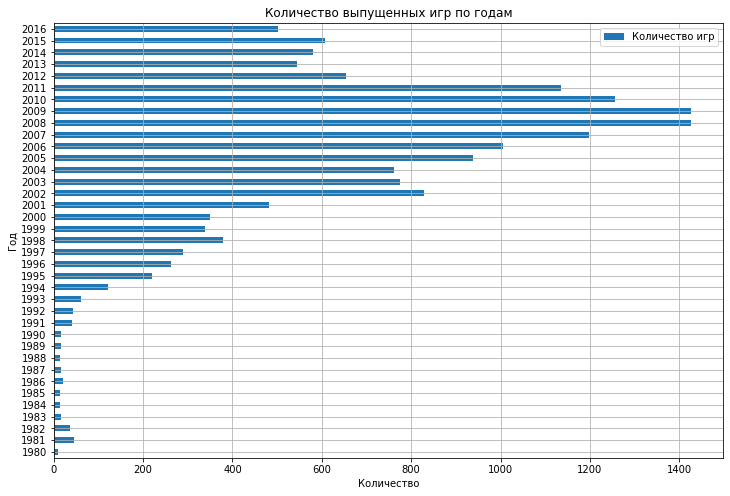

In [32]:
game_count.plot(kind='barh', grid=True, figsize=(12, 8),rot=0)
plt.xlabel('Количество')
plt.ylabel('Год')
plt.title('Количество выпущенных игр по годам')
plt.legend(['Количество игр'])
plt.show()

Из сводной таблицы можно сказать следующее - **наиболее** часто реализуемые игры были в 2005-2011 годах. 3 года с самым большим числом выпущенных игр приходится на 2008, 2009 и 2010 - это скорее всего связано с Мировым экономическим кризисом 2008 года, когда экономика многих стран мира буквально "рухнула" и многие компании буквально исчезали из-за огромных убытков. В связи с этим понятно такое большое число релизов игр, так как компаниям необходимо было получить прибыль и они делали как можно больше товара, чтобы он окупался и не позволил потерпеть убытки снова.

**Важны ли данные за все периоды?**

На мой взгляд, самые **важные данные** для нашего анализа являются со сроком не более десяти-, максимум пятнадцатилетней давности. Данные за конец прошлого века мало как повлияют на прогнозирование дальнейшего плана продаж, только увеличат количество работы и не приведут ни к какому результату. Нужно работать с той информацией, которая ещё актуальна и *действительно* может принести хоть какой-то результат - как-то повлиять на продажи. Не будем также забывать о том, что игровая индустрия сейчас очень быстро развивается, молодое поколение практически не заинтересовано в том, что было выпущено до их рождения. Из этого можно сказать, что данные до 2000 года уже **неактуальны**, пользы от них в прогнозировании **не будет**, поэтому в дальнейшем исследовании считаю, что нелогично использовать эти данные и правильнее бы для облегчения работы и анализа "*отсекать*" их. 

#### Посмотрим, как менялись продажи по платформам. 

Выберем платформы с наибольшими суммарными продажами и построим распределение по годам. 
За какой характерный срок появляются новые и исчезают старые платформы?

Для этого сгруппиуем данные по столбцу `'platform'` методом `.groupby()`, а методом `.agg()` просуммируем столбец `'sum_sales'` с данными о продажах во всех регионах и найдём минимальный год из столбца `'year_of_release'` - этот столбец будет означать в сводной таблице первую игру, которую выпустила каждая платформа. После этого отсортируем столбец `'sum_sales'` по убыванию: 

In [33]:
platform_sales = games.groupby('platform').agg({'sum_sales' : 'sum', 'year_of_release' : 'min'}).reset_index() # формируем сводную таблицу
platform_sales = platform_sales.sort_values(by='sum_sales', ascending=False).reset_index(drop=True) 

Выведем первые строки:

In [34]:
platform_sales.head(10)

,platform,sum_sales,year_of_release
0,PS2,1233.56,2000
1,X360,961.24,2005
2,PS3,931.34,2006
3,Wii,891.18,2006
4,DS,802.78,1985
5,PS,727.58,1994
6,PS4,314.14,2013
7,GBA,312.88,2000
8,PSP,289.53,2004
9,3DS,257.81,2011


Для наглядности выведем столбчатую диаграмму:

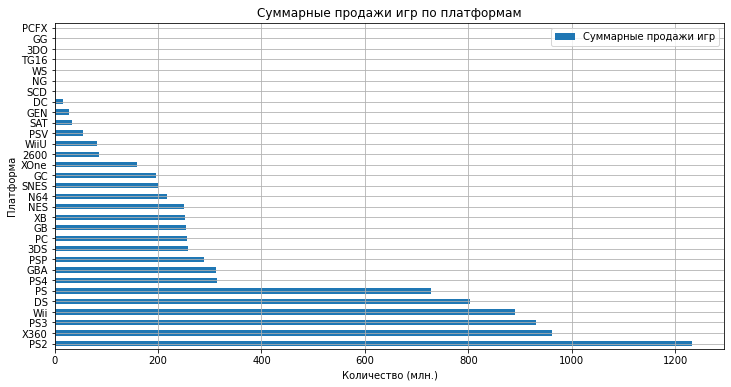

In [35]:
platform_sales.plot(x='platform', y='sum_sales', kind='barh', grid=True, figsize=(12,6))
plt.xlabel('Количество (млн.)')
plt.ylabel('Платформа')
plt.title('Суммарные продажи игр по платформам')
plt.legend(['Суммарные продажи игр'])
plt.show()

Создадим ещё одну сводную таблицу, сгруппированную также по платформам, но с последним годом релиза игры. После этого переименнуем столбцы сформированной таблицы:

In [36]:
platform_sales_1 = games.groupby('platform').agg({'year_of_release' : 'max'}).reset_index() # формируем сводную таблицу
platform_sales_1.columns = (['platform','last_year_of_release'])

Методом `.merge()` объединим `platform_sales` с `platform_sales_1`  по `'platform'` и добавим в объединённую таблицу столбец `'years_difference'`, чтобы понять, как долго каждая платформа находится на рынке и за какой срок платформа появляется и исчезает:

In [37]:
platform_sales = platform_sales.merge(platform_sales_1, on='platform')
platform_sales['years_difference'] = platform_sales['last_year_of_release'] - platform_sales['year_of_release']
# Выведем первые строки
platform_sales.head(15)

,platform,sum_sales,year_of_release,last_year_of_release,years_difference
0,PS2,1233.56,2000,2011,11
1,X360,961.24,2005,2016,11
2,PS3,931.34,2006,2016,10
3,Wii,891.18,2006,2016,10
4,DS,802.78,1985,2013,28
5,PS,727.58,1994,2003,9
6,PS4,314.14,2013,2016,3
7,GBA,312.88,2000,2007,7
8,PSP,289.53,2004,2015,11
9,3DS,257.81,2011,2016,5


С помощью метода `.value_counts()` посчитаем количество одних и тех же значений в столбце `'years_difference'` и выведем результат:

In [38]:
platform_sales['years_difference'].value_counts()

11    4
0     3
3     3
5     3
9     3
10    3
1     2
4     2
6     2
2     1
7     1
8     1
13    1
28    1
31    1
Name: years_difference, dtype: Int64

Из представленных выше результатов можно сказать, что в среднем платформа актуальна и существует около 10 лет. Однако есть некоторые платформы которые существуют и более 25 лет; это говорит о том, что они завоевали доверие пользователей и регулярно добавляют что-то новое, делают обновления и другие подобные вещи - поддерживают свой имидж и стараются не потерять доверие пользователя.

Согласно построенной сводной таблице мы определили платформы с наибольшими суммарными продажами. Построим график для 5 таких платформ - PS2, X360, PS3, Wii, DS - по годам их суммарных продаж. Диапазон определим от 2000 до 2015 годов, так как данные за более поздний период уже не актуальны, а за 2016 год - неполные:

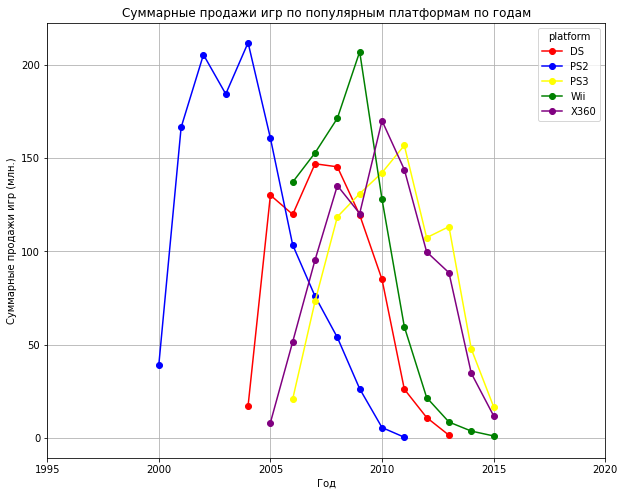

In [39]:
(games
 .query('(platform == ["PS2","X360","PS3","Wii","DS"]) & (year_of_release < 2016)')
 .pivot_table(index=['year_of_release'], columns='platform', values='sum_sales', aggfunc='sum')
 .plot(style='-o', color=['red','blue','yellow','green','purple'],xlim=(1995,2020), grid=True, figsize=(10,8))
)
plt.xlabel('Год')
plt.ylabel('Суммарные продажи игр (млн.)')
plt.title('Суммарные продажи игр по популярным платформам по годам')
plt.show()

Из данного графика можно говорить о том, то продажи данных платформ падают или их вообще нет к 2015 году, а также видно то, что мы сказали ранее, что платформа существует около 10 лет. Возможно стоит рассматривать платформы, которые появились на рынке недавно, так как платформы нового поколения имеют больше функционала и они обычно мощнее своих "предшественников".

#### Возьмём данные за соответствующий актуальный период. 

Определим актуальный период из результатов исследований проведенных ранее. Основной фактор — эти данные помогут построить прогноз на 2017 год. Не будем учитывать данные за предыдущие годы.

Таким образом проделаем следующее: скопируем датафрейм `games` в `accurate_games`, а после в `accurate_games` сделаем срез данных по годам. Игровой рынок очень быстро меняется, особенно сейчас с развитием технологий, поэтому возьмём данные,   которые более 2013 года включительно (то есть данные за последние полные 3 года): 

In [40]:
accurate_games = games.copy(deep=True)
accurate_games = accurate_games.query('year_of_release >= 2013')

Теперь, так как взяты данные за актуальный период, можно продолжить исследование.

#### Какие платформы лидируют по продажам, растут или падают? Выберем несколько потенциально прибыльных платформ.

На данном этапе проведём общий анализ данных о продажах за актуальный период: в дальнейшем рассмотрим продажи по отдельным регионам (в Северной Америке, в Европе, в Японии).

Сформулируем сводную таблицу методом `.pivot_table()` по платформам и их продажам в разных регионах мира. Передадим параметру `index` столбец `'platform'` датафрейма `accurate_games`, `values` - `'sum_sales'`, a `aggfunc` - `'sum'`. После выведем первые строки: 

In [41]:
# сформируем сводную таблицу
platform_country = accurate_games.pivot_table(index='platform', values='sum_sales', aggfunc='sum')
platform_country

,sum_sales
platform,
3DS,143.25
DS,1.54
PC,39.43
PS3,181.43
PS4,314.14
PSP,3.50
PSV,32.99
Wii,13.66
WiiU,64.63


Таблица была успешно построена.

Теперь отсортируем столбец по общей сумме проданных игр и определим какие платформы пользуются наибольшим спросом.

In [42]:
platform_country.sort_values(by='sum_sales', ascending=False)

,sum_sales
platform,
PS4,314.14
PS3,181.43
XOne,159.32
3DS,143.25
X360,136.80
WiiU,64.63
PC,39.43
PSV,32.99
Wii,13.66


Из представленных результатов можно сказать следующее:
- наиболее популярны платформы: PS4, PS3, XOne, 3DS, X360 - скорее всего это связано с тем, что эти консоли нового поколения и следовательно у них лучше функционал, мощность и графика, чем у "предшественников"	
- у консолей, которые уже давно на рынке, весьма низкие продажи

#### Построим график «ящик с усами» по глобальным продажам игр в разбивке по платформам.

Для того чтобы понять как много выбросов есть в наших данных, воспользуемся методом .boxplot() для построения "ящика с усами", куда передадим параметру `by` столбец `'platform'`, а параметру `column` - `'sum_sales'`.

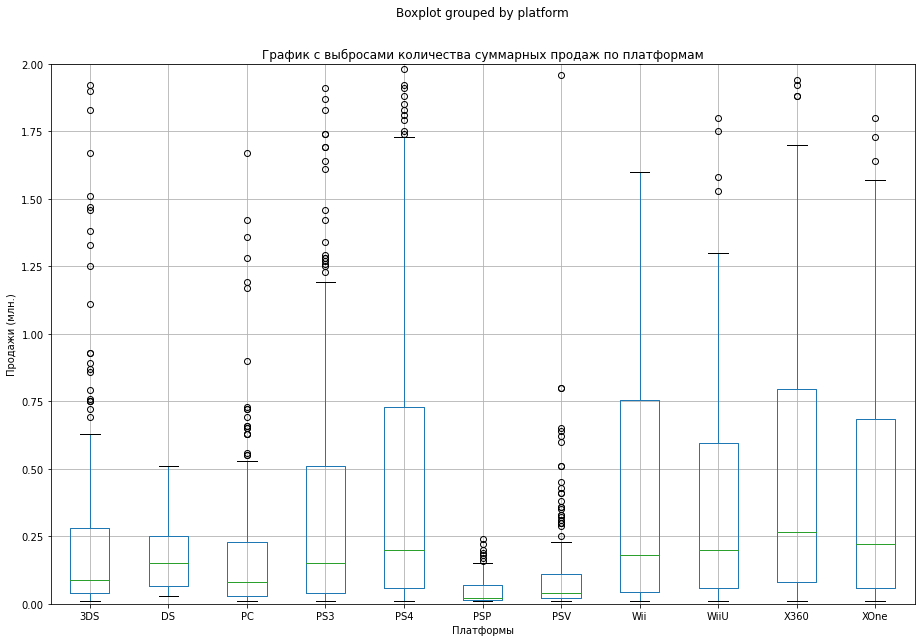

In [43]:
accurate_games.boxplot(by='platform', column='sum_sales', figsize=(15,10))
plt.ylim(0,2)
plt.xlabel('Платформы')
plt.ylabel('Продажи (млн.)')
plt.title('График с выбросами количества суммарных продаж по платформам')
plt.show()

Также воспользуемся методом `.describe()`, чтобы получить полный набор основных статистических характеристик данных, а методом `.round()` округлим все значения в наборе до двухзнаков после точки:

In [44]:
box = accurate_games.groupby('platform')['sum_sales'].describe().round(2)
box

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,303.0,0.47,1.38,0.01,0.04,0.09,0.28,14.60
DS,8.0,0.19,0.17,0.03,0.07,0.15,0.25,0.51
PC,189.0,0.21,0.35,0.01,0.03,0.08,0.23,3.05
PS3,345.0,0.53,1.45,0.01,0.04,0.15,0.51,21.05
PS4,392.0,0.80,1.61,0.01,0.06,0.20,0.73,14.63
PSP,67.0,0.05,0.06,0.01,0.02,0.02,0.07,0.24
PSV,358.0,0.09,0.15,0.01,0.02,0.04,0.11,1.96
Wii,23.0,0.59,0.92,0.01,0.04,0.18,0.76,3.58
WiiU,115.0,0.56,1.04,0.01,0.06,0.20,0.60,7.09


Добавим значения концов "усов". Эти данные понадабятся нам в следующем пункте.

In [45]:
# Нижний ус
box['down_line'] = box['25%'] - 1.5*(box['75%'] - box['25%'])
# Вехний ус
box['hign_line'] = box['75%'] + 1.5*(box['75%'] - box['25%'])

Заменим индексы в датафрейме с основными статистическими характеристиками, но без удаления старых, так как названия платформ ещё понадабятся: 

In [46]:
box = box.reset_index()

**Опишем результат:**

Из проведенного анализа графика «ящика с усами» по глобальным продажам игр в разбивке по платформам можно сказать следующее:
- *абсолютно все* платформы имеют критически много выбросов данных. 
- "усы" всех платформ не выходят за значение продаж более 2 млн.
- популярные платформы менее плотно сгруппированы, в отличии от других
- медианы продаж у всех платформ либо ниже 250 тыс. продаж, либо около 250 тыс. продаж
- разница между третьим квартилем и максимальным значением у всех платформ очень большая

#### Посмотрим, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. 

Построим диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами. Сформулируем выводы.
Соотнесём выводы с продажами игр на других платформах.

Для понимания влияния отзывов пользователей и критиков на продажи возьмём такую популярную платформу `PS4`.

Построим график зависимости продаж от оценок критиков выбранной нами платформы:

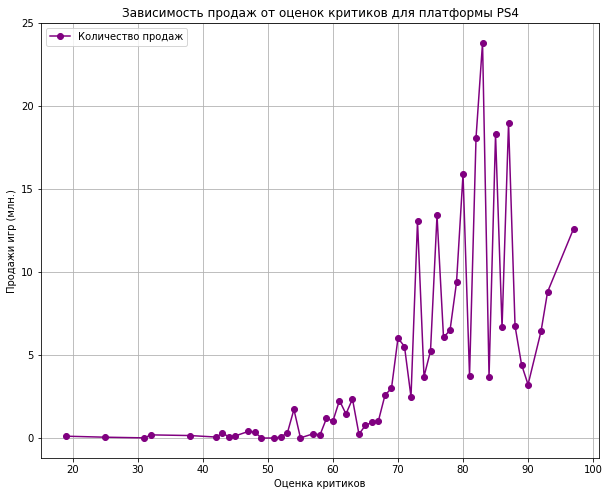

In [47]:
(
 accurate_games
    .query('platform == "PS4"')
    .pivot_table(index='critic_score', values='sum_sales', aggfunc='sum')
    .plot(style='-o', color='purple', grid=True, figsize=(10,8))
)
plt.xlabel('Оценка критиков')
plt.ylabel('Продажи игр (млн.)')
plt.title('Зависимость продаж от оценок критиков для платформы PS4')
plt.legend(['Количество продаж'])
plt.show()

Из графика прослеживается, что чем выше оценки критиков, тем выше продажи копий игр. Есть конечно отдельные случаи, когда некоторые продажи при высоком рейтинге падают, но их немного.

Теперь построим график зависимости продаж от оценок пользователей для платформы X360:

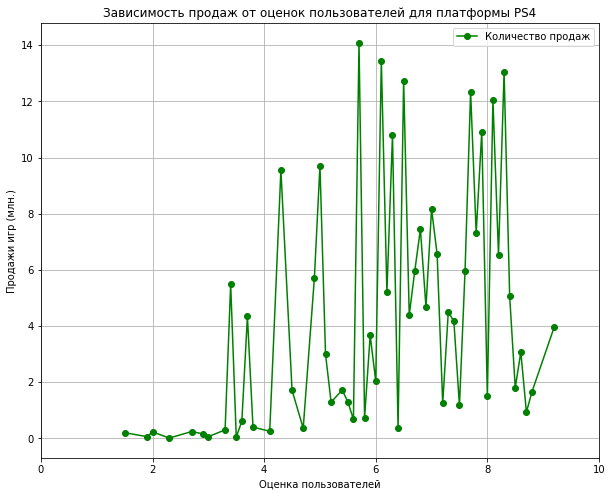

In [48]:
(
 accurate_games
    .query('(platform == "PS4")&(user_score != 724)')
    .pivot_table(index='user_score', values='sum_sales', aggfunc='sum')
    .plot(style='-o', color='green', xlim=(0,10), grid=True, figsize=(10,8))
)
plt.xlabel('Оценка пользователей')
plt.ylabel('Продажи игр (млн.)')
plt.title('Зависимость продаж от оценок пользователей для платформы PS4')
plt.legend(['Количество продаж'])
plt.show()

Из данного графика также можно увидеть зависимость, что чем выше оценки пользователей, тем выше продажи копий игр. И тут также наблюдаются случаи, когда некоторые продажи при высоком рейтинге падают, но их немного. При аппроксимации этих точек будет наблюдаться возрастающая прямая.

Построим диаграмму рассеяния между отзывами критиков и продажами: 

Для этого возьмём срез актуальных данных по выбранной нами платформе `PS4`, а также не забудем убрать данные из пользовательского рейтинга, которым присвоен *уникальный идентификатор* - `724`. После функцией `.plot()` построим график, в неё передадим следующие параметры: по оси `x` - `'critic_score'`, по оси `y` - `'sum_sales'`, тип построения `kind` - `'scatter'`, стиль `style` -`'o'`, цвет `color` - `'blue'`, диапазон по оси у `ylim=(0,5)`, коэффициент прозрачности `alpha=0.15`.

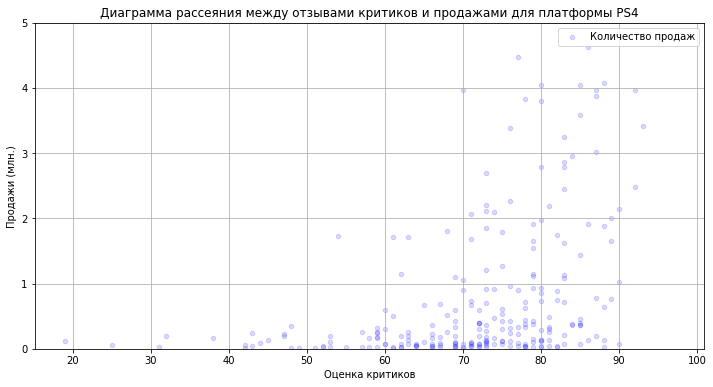

In [49]:
(
 accurate_games
    .query('(platform == "PS4")&(user_score != 724)')
    .plot(x='critic_score', y='sum_sales', kind='scatter', style='o',  
          color='blue',  ylim=(0,5), alpha=0.15, grid=True, figsize=(12,6))
)
plt.xlabel('Оценка критиков')
plt.ylabel('Продажи (млн.)')
plt.title('Диаграмма рассеяния между отзывами критиков и продажами для платформы PS4')
plt.legend(['Количество продаж'])
plt.show() 

Из диаграммы видно, что большинство оценок, которые были поставлены приходятся на сумму продаж до 1 млн. копий; также чаще всего критики ставили рейтинги от 60 до 80. 

Построим диаграмму рассеяния отзывами пользователей и продажами: 

Для этого возьмём срез актуальных данных по выбранной нами платформе `PS4`, а также не забудем убрать данные из пользовательского рейтинга, которым присвоен *уникальный идентификатор* - `724`. После функцией `.plot()` построим график, в неё передадим следующие параметры: по оси `x` - `'user_score'`, по оси `y` - `'sum_sales'`, тип построения `kind` - `'scatter'`, стиль `style` -`'o'`, цвет `color` - `'blue'`, диапазон по оси у `ylim=(0,5)`, коэффициент прозрачности `alpha=0.15`.

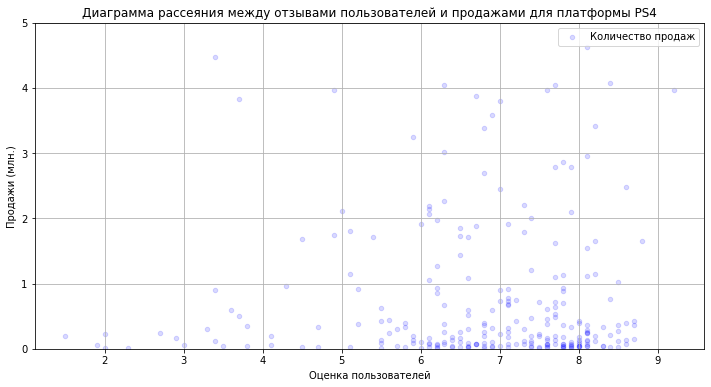

In [50]:
(
 accurate_games
    .query('(platform == "PS4")&(user_score != 724)')
    .plot(x='user_score', y='sum_sales', kind='scatter', style='o',  
          color='blue',  ylim=(0,5), alpha=0.15, grid=True, figsize=(12,6))
)
plt.xlabel('Оценка пользователей')
plt.ylabel('Продажи (млн.)')
plt.title('Диаграмма рассеяния между отзывами пользователей и продажами для платформы PS4')
plt.legend(['Количество продаж'])
plt.show() 

Из диаграммы следует, что большинство оценок, которые были поставлены приходятся на сумму продаж до 1 млн. копий; также чаще всего пользователи ставили рейтинги от 6 до 8. 

**Посчитаем корреляцию между отзывами и продажами.** 

Для начала в переменную `depend` запишем срез актуальных данных по выбранной нами платформе `X360`, а также не забудем убрать данные из пользовательского рейтинга, которым присвоен *уникальный идентификатор* - `724`. После этого "*отбросим*" данные, которые неопределены, так как в дальнейшем при попытке посчитать корреляцию с неопределёнными данными, будет выдаваться ошибка.

In [51]:
depend = ( 
    accurate_games
    .query('(platform == "PS4")&(user_score != 724)')
    .dropna(subset=['critic_score','user_score'])
)

В прошлом пункте - *п.3.5* - мы сформировали датафрейм с основными статистическими характеристиками. Обратимся к нему, чтобы получить данные по определённой платформе.

In [52]:
box[box['platform'] == "PS4"]

,platform,count,mean,std,min,25%,50%,75%,max,down_line,hign_line
4,PS4,392.0,0.8,1.61,0.01,0.06,0.2,0.73,14.63,-0.945,1.735


Из строки данных, которая была выведена, необходимо обратить внимание на последний столбец `'hign_line'` - это "верхний ус". Для того чтобы корреляция была более точной, отбросим все *выбросы* по этой платформе, то есть методом `.query()` сделаем срез данных в датафрейме `depend`: 

In [53]:
depend = depend.query('sum_sales <= 1.735')

Для вычисления корреляции необходимо, чтобы типы данных совпадали, поэтому преобразуем столбец `'critic_score'`к вещественному - в нём хранятся целочисленные данные, поэтому это преобразование никак на них не повлияет - после этого найдём корреляцию: 

In [54]:
crit_corr = depend['critic_score'].astype('float64').corr(depend['sum_sales'])
user_corr = depend['user_score'].corr(depend['sum_sales'])
print(f'Платформа PS4:')
print(f'Корреляция между отзывами критиков и продажами составляет {crit_corr:.5}')
print(f'Корреляция между отзывами пользователей и продажами составляет {user_corr:.5}')

Платформа PS4:
Корреляция между отзывами критиков и продажами составляет 0.26506
Корреляция между отзывами пользователей и продажами составляет 0.03025


Из полученных результатов корреляций можно говорить следующее: зависимости отзывов как критиков, так и пользователей от продаж - **очень слабая**. Значения корреляций очень далеки от 1 или -1, чтобы предполагать зависимость, а получившиеся у нас результаты близки к 0.

Из результатов корреляции на одну платформу нельзя говорить и обобщать это на все. Рассмотрим ещё 2 популярные платформы: `PS3` и `XOne` и их корреляции. Проделаем те же самые шаги, что и раньше для платформы PS4.

Обратимся к датафрейму с основными статистическими характеристиками, чтобы получить данные по платформам `PS3` и `XOne`.

In [55]:
box.query('(platform =="PS3")|(platform =="XOne")')

,platform,count,mean,std,min,25%,50%,75%,max,down_line,hign_line
3,PS3,345.0,0.53,1.45,0.01,0.04,0.15,0.51,21.05,-0.665,1.215
10,XOne,247.0,0.65,1.04,0.01,0.06,0.22,0.68,7.39,-0.870,1.610


Из данных, которые были выведены, необходимо обратить внимание на последний столбец `'hign_line'` - это "верхний ус". Для того чтобы корреляция была более точной, отбросим все *выбросы* по платформам, то есть методом `.query()` сделаем срез данных в датафрейме `depend_2` и `depend_2`: 

In [56]:
# Актуальные данные по платформе PS3
depend_2 = ( 
    accurate_games
    .query('(platform == "PS3")&(user_score != 724)')
    .dropna(subset=['critic_score','user_score'])
)
# Актуальные данные по платформе XOne
depend_3 = ( 
    accurate_games
    .query('(platform == "XOne")&(user_score != 724)')
    .dropna(subset=['critic_score','user_score'])
)

In [57]:
depend_2 = depend_2.query('sum_sales <= 1.215')
depend_3 = depend_3.query('sum_sales <= 1.610')

Теперь найдём корреляцию для платформ `PS3` и `XOne`:

In [58]:
crit_corr_2 = depend_2['critic_score'].astype('float64').corr(depend_2['sum_sales'])
user_corr_2 = depend_2['user_score'].corr(depend_2['sum_sales'])
print(f'Платформа PS3:')
print(f'Корреляция между отзывами критиков и продажами составляет {crit_corr_2:.5}')
print(f'Корреляция между отзывами пользователей и продажами составляет {user_corr_2:.5}')

Платформа PS3:
Корреляция между отзывами критиков и продажами составляет 0.40103
Корреляция между отзывами пользователей и продажами составляет 0.057877


In [59]:
crit_corr_3 = depend_3['critic_score'].astype('float64').corr(depend_3['sum_sales'])
user_corr_3 = depend_3['user_score'].corr(depend_3['sum_sales'])
print(f'Платформа XOne:')
print(f'Корреляция между отзывами критиков и продажами составляет {crit_corr_3:.5}')
print(f'Корреляция между отзывами пользователей и продажами составляет {user_corr_3:.5}')

Платформа XOne:
Корреляция между отзывами критиков и продажами составляет 0.41126
Корреляция между отзывами пользователей и продажами составляет 0.048474


Из результатов корреляции на платформы можно сказать:
- Корреляция между отзывами критиков и продажами для платформ `PS3` и `XOne` - **слабая**
- Корреляция между отзывами пользователей и продажами для платформ `PS3` и `XOne` - **очень слабая**

Исходя из полученных результатов, можно предположить следующее: учитывая 3 самые популярные платформы и результаты полученных корреляций, можно говорить о том, что зависимость между рейтингом как критиков, так и пользователей и продажами для всех платформ - **слабая**, а в некоторых случаях - **очень слабая**. Это говорит о том, что их оценки мало как влияют на продажи игр по платформам, и на них не нужно особо опираться для предварительного прогноза на следующий год.  

Также стоит заметить, что оценки пользователей менее объективны, так как пользователи слишком эмоционально привязаны к любимым старым играм и всегда будут считать, что прошлые игры были куда лучше, чем новые.

#### Посмотрим на общее распределение игр по жанрам. 

Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

Сформируем сводную таблицу `genre_count` по жанрам игр методом `.pivot_table()`. В таблице будет подсчитано число игр определенного жанра и суммарные продажи игр по каждому жанру. После формирования таблицы переименнуем столбцы на `'count'` и `'sum_sales'`, и отсортируем по столбцу `'count'` методом `.sort_values()`. После выведем таблицу для ознакомления:

In [60]:
genre_count = accurate_games.pivot_table(index='genre', values='sum_sales', aggfunc=['count','sum','mean','median'])
# Переименуем столбец
genre_count.columns = (['count','sum_sales','mean_sales','median_sales'])
genre_count = genre_count.sort_values(by='count', ascending=False)
genre_count

,count,sum_sales,mean_sales,median_sales
genre,,,,
Action,766,321.87,0.420196,0.110
Role-Playing,292,145.89,0.499623,0.125
Adventure,245,23.64,0.096490,0.030
Sports,214,150.65,0.703972,0.240
Shooter,187,232.98,1.245882,0.450
Misc,155,62.82,0.405290,0.100
Racing,85,39.89,0.469294,0.120
Fighting,80,35.31,0.441375,0.125
Platform,74,42.63,0.576081,0.225


Визуализируем полученную таблицу по столбцу `'count'` круговой диаграммой: 

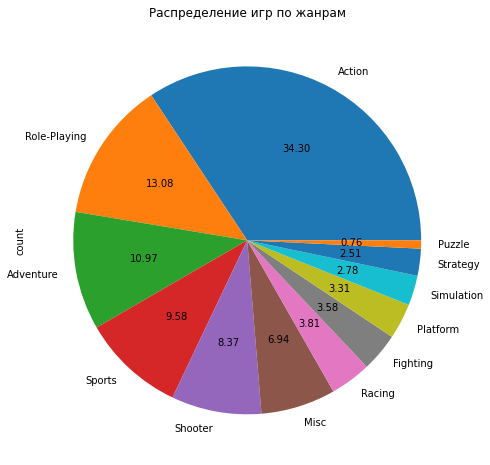

In [61]:
genre_count['count'].plot(kind='pie', autopct='%.2f', grid=True, figsize=(12, 8),rot=0)
plt.title('Распределение игр по жанрам')
plt.show()

Из диаграммы видно, что чаще всего встречаются игры жанра `Action`, `Role-Playing`, `Adventure`, наименее популярны - `Puzzle`, `Strategy`, `Simulation`. 

Теперь посмотрим, какие жанры игр продаются больше всего - отсортируем по столбцу `'sum_sales'` методом `.sort_values()`.

In [62]:
genre_count = genre_count.sort_values(by='sum_sales', ascending=False)
genre_count

,count,sum_sales,mean_sales,median_sales
genre,,,,
Action,766,321.87,0.420196,0.110
Shooter,187,232.98,1.245882,0.450
Sports,214,150.65,0.703972,0.240
Role-Playing,292,145.89,0.499623,0.125
Misc,155,62.82,0.405290,0.100
Platform,74,42.63,0.576081,0.225
Racing,85,39.89,0.469294,0.120
Fighting,80,35.31,0.441375,0.125
Adventure,245,23.64,0.096490,0.030


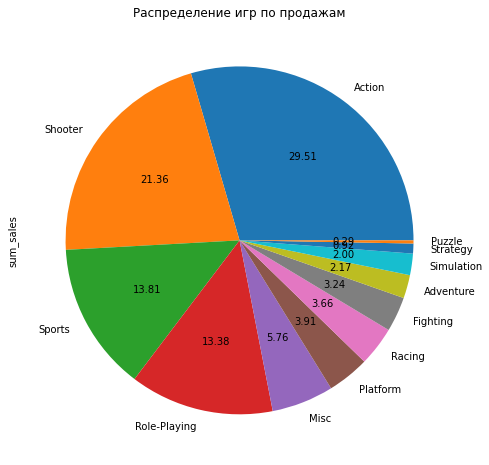

In [63]:
genre_count['sum_sales'].plot(kind='pie', autopct='%.2f', grid=True, figsize=(12, 8),rot=0)
plt.title('Распределение игр по продажам')
plt.show()

Из графика можно увидеть, что наибольшее число продаж у жанров `Action`, `Sports`, `Shooter`, наименьшее - `Puzzle`, `Strategy`, `Simulation`.

Теперь же определим жанры, которые стабильно приносят доход, так как некоторые из жанров могут брать числом, а не качеством игр.

In [64]:
genre_count = genre_count.sort_values(by='mean_sales', ascending=False)
genre_count

,count,sum_sales,mean_sales,median_sales
genre,,,,
Shooter,187,232.98,1.245882,0.450
Sports,214,150.65,0.703972,0.240
Platform,74,42.63,0.576081,0.225
Role-Playing,292,145.89,0.499623,0.125
Racing,85,39.89,0.469294,0.120
Fighting,80,35.31,0.441375,0.125
Action,766,321.87,0.420196,0.110
Misc,155,62.82,0.405290,0.100
Simulation,62,21.76,0.350968,0.100


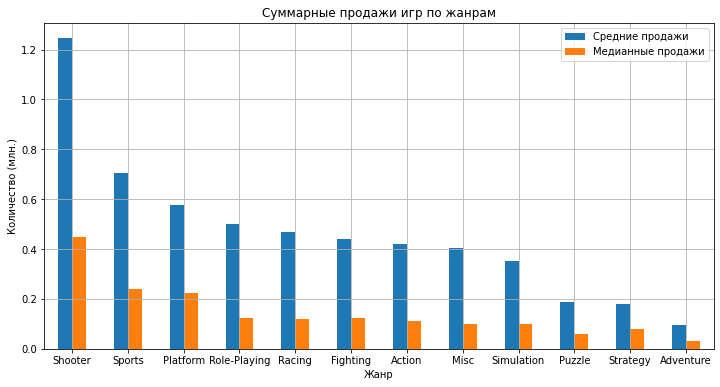

In [65]:
genre_count.plot( y=['mean_sales','median_sales'], kind='bar', grid=True, figsize=(12,6), rot=0)
plt.xlabel('Жанр')
plt.ylabel('Количество (млн.)')
plt.title('Суммарные продажи игр по жанрам')
plt.legend(['Средние продажи','Медианные продажи'])
plt.show()

Из полученного графика можно сказать, что лучше всего продаются игры жанра `Shooter`, `Sports`, `Platform`, хуже -  `Puzzle`, `Strategy`, `Adventure`.

Исходя из полученных результатов можно говорить следующее:
- хоть жанр `Action` популярнее по количеству и по сумме продаж его больше всего, но по средним продажам он всего лишь в середине списка, поэтому не следует ориентироваться на него
- наиболее выгодными для продаж в будущем можно определить жанры:  `Shooter`,`Sports`, `Platform`, `Role-Playing` - их средние и медианные продажи весьма на хорошем уровне по сравнению с остальными жанрами. 

**Промежуточный вывод:**

В результате исследовательского анализа были получены следующие результаты:

- *наиболее* часто реализуемые игры были в 2005-2011 годах. 2008, 2009 и 2010 годы имеют самое большое число выпущенных игр 
- платформы с наибольшими суммарными продажами - PS2, X360, PS3, Wii, DS 
- в среднем платформа актуальна и существует около 10 лет, однако есть и исключения
- взяли данные за актуальный период - за последние полные 3 года, то есть до 2013 года включительно
- наиболее популярные платформы: PS4, PS3, XOne, 3DS, X360
- по глобальным продажам игр *абсолютно все* платформы имеют много выбросов
- зависимость между отзывами как критиков, так и пользователей и продажами *очень слабая*
- чаще выпускаются игры жанра `Action`, `Role-Playing`, `Adventure`, меньше - `Puzzle`, `Strategy`, `Simulation`.
- наибольшее число продаж у жанров `Action`, `Sports`, `Shooter`, наименьшее - `Puzzle`, `Strategy`, `Simulation` 
- наиболее *перспективными* для продаж жанры `Shooter`,`Sports`, `Platform`, `Role-Playing`

### Шаг 4. Составление портрета пользователя каждого региона

#### Определим для пользователя каждого региона (NA, EU, JP) самые популярные платформы (топ-5)

Сформируем сводную таблицу `popular_platform` методом `.pivot_table()`, куда в качестве параметра `index` передадим столбец `'platform'`, `values` - `'na_sales'`,`'eu_sales'`,`'jp_sales'`, а `aggfunc` - `'sum'`.То есть сгруппируем данные по платформам и запишем суммарное число продаж для каждой платформы по региону:

In [66]:
# сформируем сводную таблицу
popular_platform = accurate_games.pivot_table(index='platform', values=['na_sales','eu_sales','jp_sales'], aggfunc='sum')
popular_platform

,eu_sales,jp_sales,na_sales
platform,,,
3DS,30.96,67.81,38.20
DS,0.85,0.00,0.57
PC,25.36,0.00,11.11
PS3,67.81,23.35,63.50
PS4,141.09,15.96,108.74
PSP,0.17,3.29,0.00
PSV,6.10,18.59,5.04
Wii,5.93,0.05,6.56
WiiU,19.85,10.88,29.21


Таблица была успешно построена.

Теперь отсортируем каждый столбец региона по сумме проданных игр и определим какие платформы пользуются наибольшим спросом.

Создадим список `country_sales`, в котором будут необходимые нам для сортировки данные; после циклом *for* отсортируем и выведем таблицу с каждым отсортированным столбцом по региону. Также добавим какой процент от общей суммы регионов составляет доля каждой платформы:

In [67]:
country_sales = ['na_sales','eu_sales','jp_sales']
ratio_country_sales = ['ratio_na_sales','ratio_eu_sales','ratio_jp_sales']
a = popular_platform['na_sales'] + popular_platform['eu_sales'] + popular_platform['jp_sales']
for i in range(len(country_sales)):
    popular_platform[ratio_country_sales[i]] = round((popular_platform[country_sales[i]]/a)*100,2)

					Данные по продажам  в Северной Америке

Сортировка таблицы по продажам в Северной Америке


,eu_sales,jp_sales,na_sales,ratio_na_sales,ratio_eu_sales,ratio_jp_sales
platform,,,,,,
PS4,141.09,15.96,108.74,40.91,53.08,6.00
XOne,51.59,0.34,93.12,64.20,35.57,0.23
X360,42.52,0.51,81.66,65.49,34.10,0.41
PS3,67.81,23.35,63.50,41.06,43.84,15.10
3DS,30.96,67.81,38.20,27.89,22.60,49.51


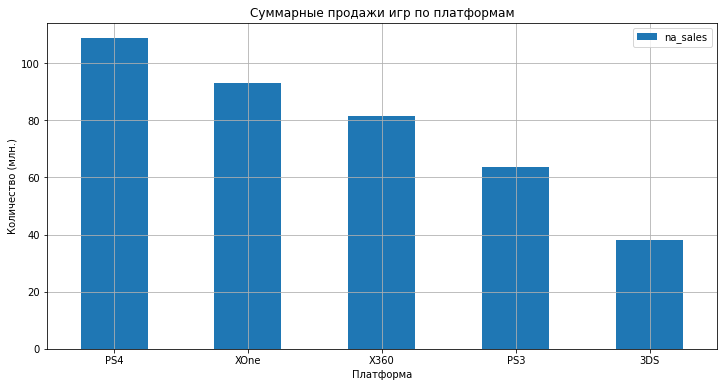

					Данные по продажам  в Европе

Сортировка таблицы по продажам в Европе


,eu_sales,jp_sales,na_sales,ratio_na_sales,ratio_eu_sales,ratio_jp_sales
platform,,,,,,
PS4,141.09,15.96,108.74,40.91,53.08,6.00
PS3,67.81,23.35,63.50,41.06,43.84,15.10
XOne,51.59,0.34,93.12,64.20,35.57,0.23
X360,42.52,0.51,81.66,65.49,34.10,0.41
3DS,30.96,67.81,38.20,27.89,22.60,49.51


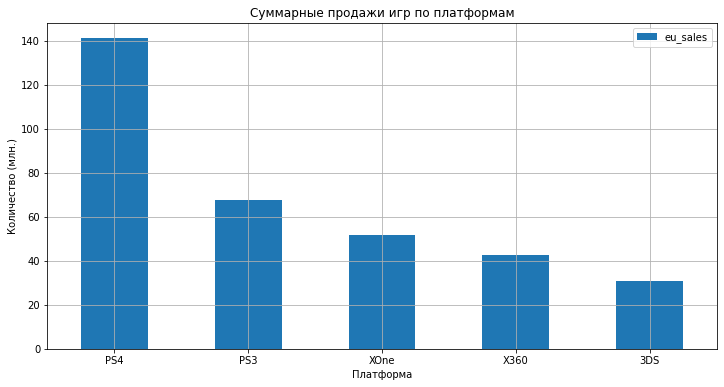

					Данные по продажам  в Японии

Сортировка таблицы по продажам в Японии


,eu_sales,jp_sales,na_sales,ratio_na_sales,ratio_eu_sales,ratio_jp_sales
platform,,,,,,
3DS,30.96,67.81,38.20,27.89,22.60,49.51
PS3,67.81,23.35,63.50,41.06,43.84,15.10
PSV,6.10,18.59,5.04,16.95,20.52,62.53
PS4,141.09,15.96,108.74,40.91,53.08,6.00
WiiU,19.85,10.88,29.21,48.73,33.12,18.15


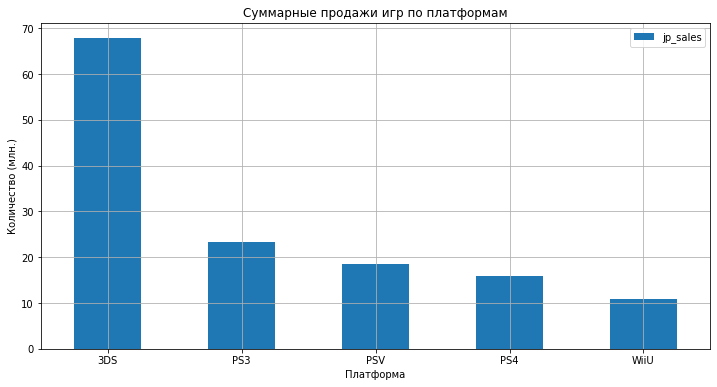

In [68]:
country = ['в Северной Америке', 'в Европе', 'в Японии']
for i in range(len(country_sales)):
    a = popular_platform.sort_values(by=country_sales[i], ascending=False)
    print('\t\t\t\t\tДанные по продажам ', country[i])
    print('\nСортировка таблицы по продажам', country[i])
    display(a.head(5))
    a = a.head(5)
    a.plot( y=country_sales[i], kind='bar', grid=True, figsize=(12,6), rot=0)
    plt.xlabel('Платформа')
    plt.ylabel('Количество (млн.)')
    plt.title('Суммарные продажи игр по платформам')
    plt.legend()
    plt.show()

Из представленных результатов можно сказать следующее:
- наиболее популярные платформы для пользователей из:
   - Северной Америки: PS4, XOne, X360, PS3, 3DS 
   - Европы: PS4, PS3, XOne, X360, 3DS
   - Японии: 3DS, PS3, PSV, PS4, WiiU
- то, что популярно в одном регионе, не говорит о том, что это будет популярно и в других; наиболее наглядно это представлено в таблице по продажам в Японии, где платформа 3DS пользуется большим спросом в Японии (49.51%), чем в Северной Америке и Европе (27.89% и 22.6% соответственно)
- количество продаж(их рост или спад) возможно зависит от менталитета пользователей, а также от компаний производителей платформ: например, в Японии приоритет отдается платформам от компании Nintendo (японская компания), чем другим (европейским и американским)
- топ-5 платформ в Северной Америке и Европе полностью совпадает

#### Определим для пользователя каждого региона (NA, EU, JP) самые популярные жанры (топ-5)

Сформируем сводную таблицу `popular_genre` методом `.pivot_table()`, куда в качестве параметра `index` передадим столбец `'genre'`, `values` - `'na_sales'`,`'eu_sales'`,`'jp_sales'`, а `aggfunc` - `'sum'`.То есть сгруппируем данные по жанрам и запишем суммарное число продаж для каждой платформы по региону:

In [69]:
popular_genre = accurate_games.pivot_table(index='genre', values=['na_sales','eu_sales','jp_sales'], aggfunc='sum')

Теперь, как и в *пункте 4.1* отсортируем каждый столбец региона по сумме проданных игр и определим какие жанры пользуются наибольшой популярностью.

Создадим список `country_sales`, в котором будут необходимые нам для сортировки данные; после циклом *for* отсортируем и выведем таблицу с каждым отсортированным столбцом по региону.


Сортировка таблицы по жанрам  в Северной Америке


,eu_sales,jp_sales,na_sales
genre,,,
Action,118.13,40.49,126.05
Shooter,87.86,6.61,109.74
Sports,60.52,5.41,65.27
Role-Playing,36.97,51.04,46.40
Misc,20.04,9.20,27.49



Сортировка таблицы по жанрам  в Европе


,eu_sales,jp_sales,na_sales
genre,,,
Action,118.13,40.49,126.05
Shooter,87.86,6.61,109.74
Sports,60.52,5.41,65.27
Role-Playing,36.97,51.04,46.40
Racing,20.19,2.30,12.96



Сортировка таблицы по жанрам  в Японии


,eu_sales,jp_sales,na_sales
genre,,,
Role-Playing,36.97,51.04,46.40
Action,118.13,40.49,126.05
Misc,20.04,9.20,27.49
Fighting,8.55,7.65,15.55
Shooter,87.86,6.61,109.74


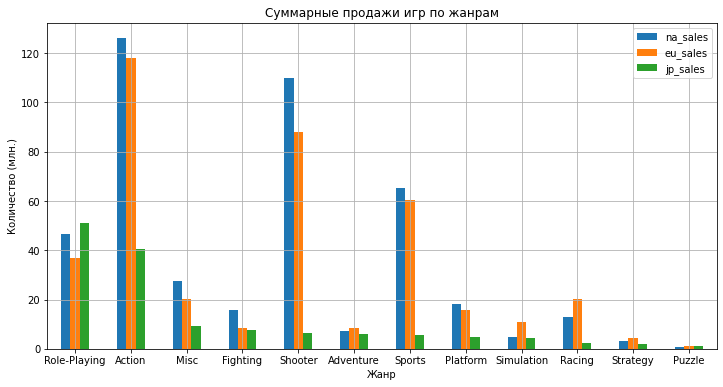

In [70]:
country_sales = ['na_sales','eu_sales','jp_sales']
country = ['в Северной Америке', 'в Европе', 'в Японии']
for i in range(len(country_sales)):
    a = popular_genre.sort_values(by=country_sales[i], ascending=False)
    print('\nСортировка таблицы по жанрам ', country[i])
    display(a.head())
    
a.plot( y=['na_sales','eu_sales','jp_sales'], kind='bar', grid=True, figsize=(12,6), rot=0)
plt.xlabel('Жанр')
plt.ylabel('Количество (млн.)')
plt.title('Суммарные продажи игр по жанрам')
plt.legend()
plt.show()

Из представленных результатов можно говорить следующее:
- наиболее популярные жанры для пользователей из:
   - Северной Америки: Action, Shooter, Sports, Role-Playing, Misc,  
   - Европы: Action, Shooter, Sports, Role-Playing, Racing
   - Японии: Role-Playing, Action, Misc, Fighting, Shooter  
- у пользователей этих регионов в топ-5 совпадают 4 жанра по играм: Action, Shooter, Sports, Role-Playing,

#### Влияет ли рейтинг ESRB на продажи в отдельном регионе?

Снова сформируем сводную таблицу `popular_rating` методом `.pivot_table()`, куда в качестве параметра `index` передадим столбец `'rating'`, `values` - `'na_sales'`,`'eu_sales'`,`'jp_sales'`, а `aggfunc` - `'sum'`.То есть сгруппируем данные по рейтингу ESRB и запишем суммарное число продаж по региону:

In [71]:
popular_rating = accurate_games.pivot_table(index='rating', values=['na_sales','eu_sales','jp_sales'], aggfunc='sum')
popular_rating

,eu_sales,jp_sales,na_sales
rating,,,
E,83.36,15.14,79.05
E10+,42.69,5.89,54.24
M,145.32,14.11,165.21
T,41.95,20.59,49.79
UNK,78.91,85.05,89.42


Снова обратимся к поиску информации из Интернета, чтобы понять, как происходит категоризация игры и какие обозначения даются при этом системой оценки рейтинга игр *ESRB*, так как данные об этом нигде указаны и пояснений нам тоже не было переданно. Из результатов поиска будем ссылаться на данный источник информации - (*URL: https://www.kingston.com/ru/blog/gaming/understanding-video-games-age-ratings-esrb-pegi*). Оттуда возьмём необходимое описание аббревиатур для понимания: 
- EC:	Для детей младшего возраста. Подходит для детей от 3 лет, неприемлемое содержание отсутствует.
- E:	Подходит для всех возрастных категорий. Игра не должна содержать звуков или изображений, которые могут напугать маленьких детей. Не должна использоваться ненормативная лексика.
- E10+:	Подходит для лиц старше 10 лет. Игра может содержать умеренные формы насилия, а некоторые сцены могут пугать детей. 
- T:	Подходит для лиц старше 13 лет. Игра может содержать более реалистичные и натуралистические сцены насилия.
- M:	Подходит для лиц старше 17 лет. Этот рейтинг используется, когда насилие становится реалистичным и похожим на реальную жизнь. Также может присутствовать ненормативная лексика, употребление табака, алкоголя или запрещенных наркотиков.
- AO:	Подходит для взрослых старше 18 лет. Классификация «для взрослых» используется, когда в игре присутствует крайний уровень насилия и немотивированного убийства. Также может присутствовать романтизация наркотиков, азартных игр и сексуальной активности. 
- RP:	Категория ещё не присвоена. Играм с категорией RP еще не присвоен окончательный рейтинг ESRB.

Теперь, как и в *пункте 4.1* отсортируем каждый столбец региона по сумме проданных игр и определим с каким рейтингом *ESRB* чаще продаются игры в каждом регионе.

Создадим список `country_sales`, в котором будут необходимые нам для сортировки данные; после циклом *for* отсортируем и выведем таблицу с каждым отсортированным столбцом по региону.


Сортировка таблицы по продажам определенного рейтинга в Северной Америке


,eu_sales,jp_sales,na_sales
rating,,,
M,145.32,14.11,165.21
UNK,78.91,85.05,89.42
E,83.36,15.14,79.05
E10+,42.69,5.89,54.24
T,41.95,20.59,49.79



Сортировка таблицы по продажам определенного рейтинга в Европе


,eu_sales,jp_sales,na_sales
rating,,,
M,145.32,14.11,165.21
E,83.36,15.14,79.05
UNK,78.91,85.05,89.42
E10+,42.69,5.89,54.24
T,41.95,20.59,49.79



Сортировка таблицы по продажам определенного рейтинга в Японии


,eu_sales,jp_sales,na_sales
rating,,,
UNK,78.91,85.05,89.42
T,41.95,20.59,49.79
E,83.36,15.14,79.05
M,145.32,14.11,165.21
E10+,42.69,5.89,54.24


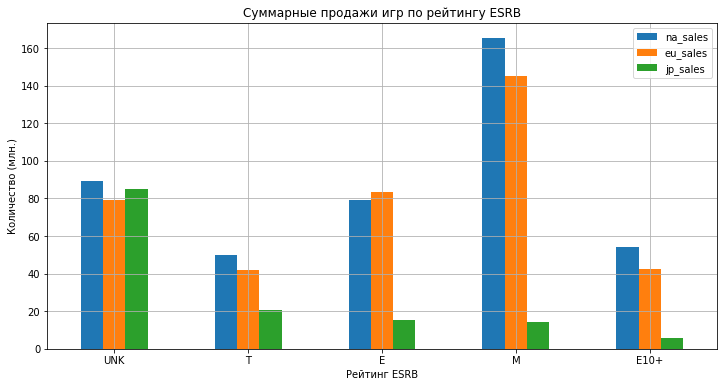

In [72]:
country_sales = ['na_sales','eu_sales','jp_sales']
country = ['в Северной Америке', 'в Европе', 'в Японии']
for i in range(len(country_sales)):
    a = popular_rating.sort_values(by=country_sales[i], ascending=False)
    print('\nСортировка таблицы по продажам определенного рейтинга', country[i])
    display(a)
    
a.plot( y=['na_sales','eu_sales','jp_sales'], kind='bar', grid=True, figsize=(12,6), rot=0)
plt.xlabel('Рейтинг ESRB')
plt.ylabel('Количество (млн.)')
plt.title('Суммарные продажи игр по рейтингу ESRB')
plt.legend()
plt.show()

Из результатов можно говорить следующее:
- Продаж игр с рейтингом EC, AO, RP вообще нет
- Продаж игр в Японии с данной системой оценивания очень мало
- Более 200 млн проданных игр в каждом регионе имеют неизвестный рейтинг оценивания

Отвечая на поставленный вопрос - влияет ли рейтинг ESRB на продажи в отдельном регионе - можно говорить - **нет**. Как ранее упоминалось в исследовании, некоторые страны имеют либо свою собственную систему, либо организации оценивания игр расположенные в той же стране. Например, в Японии производители консолей требуют от издателей видеоигр иметь маркировку *Организации по рейтингу компьютерных развлечений CERO*; *CERO* занимается маркировкой видеоигр в Японии, или в Австралии за маркировку игр отвечает *госорган – Австралийский совет по маркировке (Australian Classification Board - ACB)*, или система *PEGI*, которая используется в Великобритании и ряде других европейских стран. Поэтому говорить о том, что существует связь продаж от определенного рейтинга просто-напросто неуместно и неправильно, так как игра может иметь рейтинг по другой системе оценивания, **но** обозначать абсолютно тот же самый рейтинг, если его "перевести" в систему *ESRB*. К тому же рейтинг всего лишь определяет возраст, с которого рекомендованно играть пользователю. Обычно при покупке игры пользователь мало смотрит на рейтинг игры, он отмечает для себя графику, сюжет, наличие свободной игры, возможность командной игры и многое другое. 

**Промежуточный вывод:**

В результате составление портрета пользователя каждого региона было определено следующее:
- наиболее популярные платформы для пользователей из:
   - Северной Америки: PS4, XOne, X360, PS3, 3DS 
   - Европы: PS4, PS3, XOne, X360, 3DS
   - Японии: 3DS, PS3, PSV, PS4, WiiU
- наиболее популярные жанры для пользователей из:
   - Северной Америки: Action, Shooter, Sports, Role-Playing, Misc,  
   - Европы: Action, Shooter, Sports, Role-Playing, Racing
   - Японии: Role-Playing, Action, Misc, Fighting, Shooter 
- то, что популярно в одном регионе, не говорит о том, что это будет популярно и в других
- рейтинг *ESRB* никак не влияет на продажи в отдельном регионе - некоторые страны имеют либо свою собственную систему, либо организации оценивания игр расположенные в той же стране (система *PEGI* - Великобритания, Австралийский совет по маркировке (государственный орган) в Австралии, Организация по рейтингу компьютерных развлечений *CERO* в Японии)

### Шаг 5. Проверка гипотез

Проверим гипотезы и определим какую стоит принять, а какую отвергнуть.

#### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Для проверки этой гипотезы воспользуемся *двусторонней* гипотезой о равенстве средних двух генеральных совокупностей. Для этого в специальный метод `scipy.stats.ttest_ind()` передадим в качестве параметров: `Xbox_One_score['user_score']` и `PC_score['user_score']` - наборы значений пользовательских рейтингов платформ Xbox One и PC соответственно, которые содержат выборки, `alternative` — текстовый параметр, задающий альтернативную гипотезу примем равным `'two-sided'`. То есть аргумент `'two-sided'` будет обозначать и проверять следующую альтернативную гипотезу - *«Среднее значение первой генеральной совокупности не равно среднему значению второй генеральной совокупности»*. Также передадим параметр `equal_var` равным `False`. Это обусловленно тем, что неизвестен размер передаваемых данных и следовательно, если предположить, что выборки разного размера или имеются сомнения, что дисперсии у генеральных совокупностей разные, то лучше будет с нашей стороны указать параметр `equal_var` равным именно `False`. Была выбрана именна эта гипотеза, так как были взяты данные за актуальный, определённый период времени; не было результатов исследований до и после какого-то момента одного и того же, данные не зависят друг от друга.

**Сформулируем гипотезы:**

*Н0(Нулевая гипотеза):* Среднее генеральной совокупности пользовательских рейтингов платформы Xbox One и платформы PC **равно**.

*Н1(Альтернативная гипотеза):* Среднее генеральной совокупности пользовательских рейтингов платформы Xbox One и платформы PC **не равно**.

Проверим сформулированные гипотезы.

Установим уровень статистической значимости. Так как размер выборки напрямую влияет на статистические выводы, то с большей выборкой больше шансов обнаружить реальное различие, если оно существует, поэтому выберем более строгий уровень значимости без ущерба для статистической мощности и установим параметр `alpha` примем равным `0.01`.

In [73]:
alpha = 0.01 # уровень статистической значимости

Xbox_One_score = accurate_games.dropna(subset=['user_score']).query('(platform == "XOne")&(user_score != 724)')
PC_score = accurate_games.dropna(subset=['user_score']).query('(platform == "PC")&(user_score != 724)')

results = st.ttest_ind(Xbox_One_score['user_score'], PC_score['user_score'], equal_var=False, alternative='two-sided')

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение: 0.14759594013430463
Не отвергаем нулевую гипотезу


После проверки гипотезы можно наблюдать, что принимается нулевая гипотеза, то есть *среднее генеральной совокупности пользовательских рейтингов платформы Xbox One и платформы PC* **равно**. Ранее это можно было как-то предположить, исходя из количества продаж, рейтинга критиков или популярности жанра по каждому региону. Теперь же мы проверили данную гипотезу и у нас *нет оснований* утверждать, что средние пользовательские рейтинги платформ Xbox One и PC значимо различаются.

#### Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

Для проверки этой гипотезы воспользуемся *двусторонней* гипотезой о равенстве средних двух генеральных совокупностей. Для этого в специальный метод `scipy.stats.ttest_ind()` передадим в качестве параметров: `Action_score['user_score']` и `Sports_score['user_score']` - наборы значений пользовательских рейтингов жанров Action и Sports соответственно, которые содержат выборки, `alternative` — текстовый параметр, задающий альтернативную гипотезу примем равным `'two-sided'`. То есть аргумент `'two-sided'` будет обозначать и проверять следующую альтернативную гипотезу - *«Среднее значение первой генеральной совокупности не равно среднему значению второй генеральной совокупности»*. Также передадим параметр `equal_var` равным `False`. Это обусловленно тем, что неизвестен размер передаваемых данных и следовательно, если предположить, что выборки разного размера или имеются сомнения, что дисперсии у генеральных совокупностей разные, то лучше будет с нашей стороны указать параметр `equal_var` равным именно `False`. Была выбрана именна эта гипотеза, так как были взяты данные за актуальный, определённый период времени; не было результатов исследований до и после какого-то момента одного и того же, данные не зависят друг от друга.

**Сформулируем гипотезы:**

*Н0(Нулевая гипотеза):* Среднее генеральной совокупности пользовательских рейтингов жанров Action и Sports **равно**.

*Н1(Альтернативная гипотеза):* Среднее генеральной совокупности пользовательских рейтингов жанров Action и Sports **не равно**.

Проверим сформулированные гипотезы.

Установим уровень статистической значимости. Так как размер выборки напрямую влияет на статистические выводы, то с большей выборкой больше шансов обнаружить реальное различие, если оно существует, поэтому выберем более строгий уровень значимости без ущерба для статистической мощности и установим параметр `alpha` примем равным `0.01`.

In [74]:
alpha = 0.01 # уровень статистической значимости

Action_score = accurate_games.dropna(subset=['user_score']).query('(genre == "Action")&(user_score != 724)')
Sports_score = accurate_games.dropna(subset=['user_score']).query('(genre == "Sports")&(user_score != 724)')

results = st.ttest_ind(Action_score['user_score'], Sports_score['user_score'], equal_var=False, alternative='two-sided')

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение: 1.4460039700704315e-20
Отвергаем нулевую гипотезу


После проверки гипотезы можно наблюдать, что принимается альтернативная гипотеза, то есть *среднее генеральной совокупности пользовательских рейтингов жанров Action и Sports* **не равно**. Ранее это можно было предположить, исходя из количества продаж, рейтинга критиков по каждому региону. Теперь же мы проверили данную гипотезу и у нас *есть основания* утверждать, что пользовательские оценки жанров Action и Sports **разные**. 

 ### Шаг 6. Общий вывод

В результате проведенного исследования были получены следующие результаты:
- изменены названия столбцов - приведены к правильному виду записи (прописные буквы,  латинский алфавит, "змеевидная" запись(через нижнее подчеркивание))
- преобразованы типы данных в столбцах `'year_of_release'`, `'critic_score'`, `'user_score'` на правильный
- для переменной `'tbd'`  был введен *уникальный идентификатор* - `724` в столбце `'user_score'`
- обработаны пропуски в столбцах датафрейма, где было возможно
- посчитаны суммарные продажи по всем регионам и добавлены в новый столбец `'sum_sales'`
- датафрейм был приведён к удобному виду для чтения и анализа
- платформы с наибольшими суммарными продажами - PS2, X360, PS3, Wii, DS 
- в среднем платформа актуальна и существует около 10 лет, однако есть и исключения
- взяли данные за актуальный период - за последние полные 3 года, то есть до 2013 года включительно
- наиболее популярные платформы: PS4, PS3, XOne, 3DS, X360
- то, что популярно в одном регионе, не говорит о том, что это будет популярно и в других
- количество продаж(их рост или спад), возможно, зависит от менталитета пользователей, а также от компаний производителей платформ
- по глобальным продажам игр *абсолютно все* платформы имеют много выбросов
- зависимость между отзывами критиков и пользователей и продажами *очень слабая*
- чаще выпускаются игры жанра `Action`, `Role-Playing`, `Adventure`, меньше - `Puzzle`, `Strategy`, `Simulation`.
- наибольшее число продаж у жанров `Action`, `Sports`, `Shooter`, наименьшее - `Puzzle`, `Strategy`, `Simulation` 
- наиболее *перспективными* для продаж жанры `Shooter`,`Sports`, `Platform`, `Role-Playing`
- наиболее популярные платформы для пользователей из:
   - Северной Америки: PS4, XOne, X360, PS3, 3DS 
   - Европы: PS4, PS3, XOne, X360, 3DS
   - Японии: 3DS, PS3, PSV, PS4, WiiU
- наиболее популярные жанры для пользователей из:
   - Северной Америки: Action, Shooter, Sports, Role-Playing, Misc,  
   - Европы: Action, Shooter, Sports, Role-Playing, Racing
   - Японии: Role-Playing, Action, Misc, Fighting, Shooter 
- рейтинг ESRB никак *не влияет* на продажи в отдельном регионе - страны могут выбирать разные системы оценивания
- Проверили гипотезу и *нашли основания* утверждать о том, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые
- Проверили гипотезу и *нашли основания* утверждать о том, что средние пользовательские рейтинги жанров Action и Sports разные.

**Исходя из полученных результатов, можно сказать следующее о предстоящей рекламной кампании на следующий год:**
- Выбирать стоит платформы "нового" поколения, которые на рынке менее 10 лет
- Будем учитывать платформы, которые наиболее популярны *в большинстве* регионов: PS4, PS3, XOne, X360, 3DS 
- Сфокусируемся на наиболее перспективных жанрах игр: `Shooter`,`Sports`, `Platform`, `Role-Playing`
- Будем учитывать предпочтения пользователей стран к играм на определённой платформе - таких как в Японии
- Можно попробовать продавать игры не только с рейтингом *ESRB*, но и другими популярными рейтингами, как *PEGI* 